In [46]:
import pandas  as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [3]:
orders = pd.read_csv("orders.csv")
products = pd.read_csv("products.csv")

In [4]:
print(orders.head())

   order_id  order_date product_id  quantity  region
0      1001  2024-06-12       P002       1.0  South 
1      1002  2024-03-11       P004       1.0   South
2      1003  2024-01-27       P002       2.0    West
3      1004  2024-01-09       P001       1.0   South
4      1005  2024-02-29       P001       2.0   South


In [5]:
print(products.head())

  product_id         product_name     category  unit_price
0       P001       Wireless Mouse  Accessories         799
1       P002  Mechanical Keyboard  Accessories        2499
2       P003            USB-C Hub  Accessories        1299
3       P004         Laptop Stand       Office        1099
4       P005            Webcam HD  Electronics        1999


In [6]:
print(orders.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 315 entries, 0 to 314
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   order_id    315 non-null    int64  
 1   order_date  315 non-null    object 
 2   product_id  315 non-null    object 
 3   quantity    280 non-null    float64
 4   region      305 non-null    object 
dtypes: float64(1), int64(1), object(3)
memory usage: 12.4+ KB
None


In [7]:
print(products.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   product_id    8 non-null      object
 1   product_name  8 non-null      object
 2   category      8 non-null      object
 3   unit_price    8 non-null      int64 
dtypes: int64(1), object(3)
memory usage: 388.0+ bytes
None


In [8]:
print(orders.shape)

(315, 5)


In [9]:
print(products.shape)

(8, 4)


In [10]:
orders.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 315 entries, 0 to 314
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   order_id    315 non-null    int64  
 1   order_date  315 non-null    object 
 2   product_id  315 non-null    object 
 3   quantity    280 non-null    float64
 4   region      305 non-null    object 
dtypes: float64(1), int64(1), object(3)
memory usage: 12.4+ KB


In [11]:
orders.isnull().sum()

order_id       0
order_date     0
product_id     0
quantity      35
region        10
dtype: int64

In [12]:
orders.duplicated().sum()

np.int64(14)

In [13]:
# Step 1: Remove exact duplicate rows
orders = orders.drop_duplicates().copy()


In [14]:
# Step 2: Fix inconsistent region names (extra spaces, wrong casing)
orders['region'] = orders['region'].str.strip().str.title()


In [15]:
# Step 3: Handle missing quantity — fill with 1 (most common order size, reasonable default)
orders['quantity'] = orders['quantity'].fillna(1)


In [16]:
# Step 4: Handle missing region — label as "Unknown" instead of dropping (still valid order data)
orders['region'] = orders['region'].fillna('Unknown')


In [17]:

# Step 5: Fix order_date — some are 'unknown' text instead of real dates
orders['order_date'] = pd.to_datetime(orders['order_date'], errors='coerce')
# 'errors=coerce' turns unparseable dates (like 'unknown') into NaT (missing date), instead of crashing

In [48]:
merged = orders.merge(products, on='product_id', how='left')
merged['revenue'] = merged['quantity'] * merged['unit_price']

In [34]:

print(orders.isnull().sum())
print(orders.duplicated().sum())
print(orders['region'].unique())
print(orders.shape)


order_id      0
order_date    5
product_id    0
quantity      0
region        0
dtype: int64
0
['South' 'West' 'North' 'Unknown' 'East']
(301, 5)


In [35]:
products = pd.read_csv('products.csv')

In [36]:
# Total revenue
print("Total Revenue:", merged['revenue'].sum())

Total Revenue: 1221401.0


In [37]:
# Revenue by category
print(merged.groupby('category')['revenue'].sum().sort_values(ascending=False))

category
Electronics    814403.0
Accessories    298217.0
Office         108781.0
Name: revenue, dtype: float64


In [38]:
# Revenue by region
print(merged.groupby('region')['revenue'].sum().sort_values(ascending=False))

region
South      413831.0
North      353840.0
West       243216.0
East       161329.0
Unknown     49185.0
Name: revenue, dtype: float64


In [39]:
# Top 5 products by revenue
print(merged.groupby('product_name')['revenue'].sum().sort_values(ascending=False).head())

product_name
Monitor 24"            566937.0
Mechanical Keyboard    187425.0
Webcam HD              165917.0
Bluetooth Speaker       81549.0
Laptop Stand            70336.0
Name: revenue, dtype: float64


In [40]:
# Average order value
print("Average Order Value:", merged['revenue'].mean().round(2))

Average Order Value: 4057.81


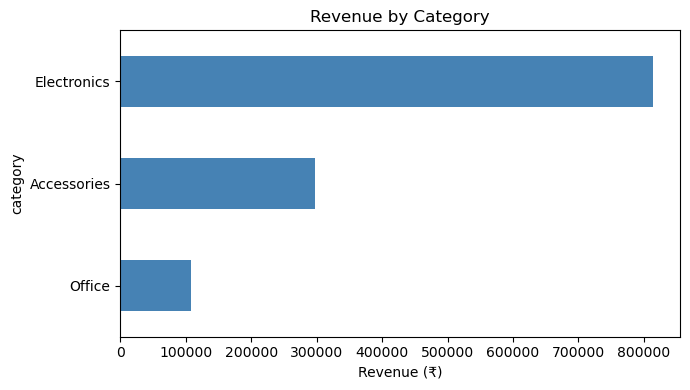

In [41]:

merged.groupby('category')['revenue'].sum().sort_values().plot(kind='barh', color='steelblue', figsize=(7,4))
plt.title('Revenue by Category')
plt.xlabel('Revenue (₹)')
plt.tight_layout()
plt.show()

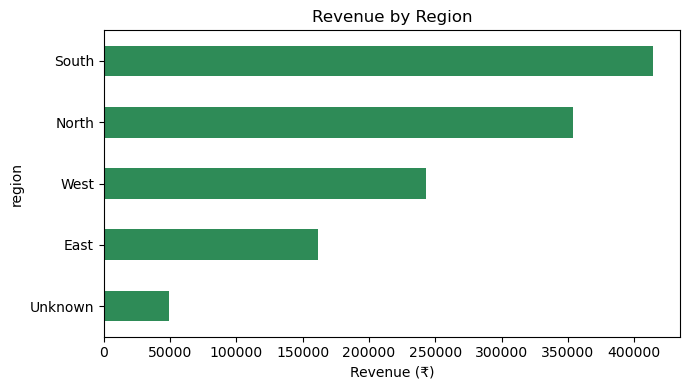

In [42]:

merged.groupby('region')['revenue'].sum().sort_values().plot(kind='barh', color='seagreen', figsize=(7,4))
plt.title('Revenue by Region')
plt.xlabel('Revenue (₹)')
plt.tight_layout()
plt.show()

In [44]:
merged.to_csv('merged_sales_data.csv', index=False)
print("Exported successfully")

Exported successfully


In [45]:
print(merged.shape)
print("merged is ready")

(301, 9)
merged is ready


In [47]:
print("Current folder:", os.getcwd())
print("Files here:", os.listdir())

Current folder: C:\Users\HP
Files here: ['.anaconda', '.cache', '.codex', '.conda', '.continuum', '.copilot', '.gitconfig', '.idlerc', '.ipynb_checkpoints', '.ipython', '.jupyter', '.matplotlib', '.python_history', '.sbx-denybin', '.virtual_documents', '.vscode', '.vscode-shared', 'AI-CRM-HCP', 'AppData', 'Application Data', 'configuration-Office2019Enterprise.xml', 'configuration-Office2021Enterprise.xml', 'configuration-Office365-x64.xml', 'configuration-Office365-x86.xml', 'Contacts', 'Cookies', 'COVID19_Patient_Risk_Analysis.csv', 'Desktop', 'DISM', 'Documents', 'Downloads', 'Favorites', 'fulfillment.db', 'fulfillment_raw.csv', 'JSON', 'Links', 'Local Settings', 'merged_sales_data.csv', 'Music', 'My Documents', 'netflix_customer_churn.csv', 'NetHood', 'NTUSER.DAT', 'ntuser.dat.LOG1', 'ntuser.dat.LOG2', 'NTUSER.DAT{28be09f9-957f-11f0-933a-dbb2e57ce497}.TxR.0.regtrans-ms', 'NTUSER.DAT{28be09f9-957f-11f0-933a-dbb2e57ce497}.TxR.1.regtrans-ms', 'NTUSER.DAT{28be09f9-957f-11f0-933a-dbb2e5